# North DFW Housing Affordability Crisis
## Notebook 05: Model Evaluation & Tableau Export

**Author:** Alejandro Molina  
**GitHub:** https://github.com/chooseyourtacoday  
**Date:** 2026

---

### Notebook Goal
1. Evaluate model performance in depth — where it works well and where it struggles
2. Answer the five original business questions using model results
3. Export clean, Tableau-ready datasets for dashboard visualization

### Business Questions Answered
| # | Question | Answer |
|---|----------|--------|
| 1 | Are we heading toward a correction? | Yes — model forecasts declines in all cities |
| 2 | Who is most at risk? | Prosper and Frisco buyers at current prices |
| 3 | Is the wage gap the driver? | Yes — 2022 gap of -23.5% confirms it |
| 4 | What does 2 years look like? | Soft correction, not a crash |
| 5 | What could help? | Supply increase and wage growth are the levers |

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

FEATURES_DIR    = os.path.join('data', 'features')
PREDICTIONS_DIR = os.path.join('data', 'predictions')
TABLEAU_DIR     = os.path.join('data', 'tableau')
os.makedirs(TABLEAU_DIR, exist_ok=True)

# Load feature dataset
df = pd.read_csv(
    os.path.join(FEATURES_DIR, 'dfw_housing_features.csv'),
    parse_dates=['date']
)

# Load predictions
predictions = pd.read_csv(
    os.path.join(PREDICTIONS_DIR, 'home_value_predictions.csv'),
    parse_dates=['date']
)

forecast_summary = pd.read_csv(
    os.path.join(PREDICTIONS_DIR, 'forecast_summary.csv')
)

importance_df = pd.read_csv(
    os.path.join(PREDICTIONS_DIR, 'feature_importance.csv')
)

print('All files loaded.')
print(f'Features     : {df.shape}')
print(f'Predictions  : {predictions.shape}')

All files loaded.
Features     : (1755, 28)
Predictions  : (1911, 5)


## Step 2: Rebuild Model for Residual Analysis
We retrain the model here to generate residuals (prediction errors) for evaluation.

In [2]:
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])

FEATURE_COLS = [
    'city_encoded', 'year', 'month', 'mortgage_rate', 'total_units',
    'collin_avg_annual_pay', 'population', 'median_income',
    'price_to_income_ratio', 'mortgage_burden_pct', 'home_value_mom',
    'home_value_yoy', 'wage_growth_yoy', 'affordability_gap',
    'supply_pressure', 'affordability_index'
]

TARGET_COL = 'home_value'
SPLIT_DATE = '2024-01-01'

model_df = df[FEATURE_COLS + [TARGET_COL, 'date', 'city', 'zip_code']].dropna()

train = model_df[model_df['date'] < SPLIT_DATE]
test  = model_df[model_df['date'] >= SPLIT_DATE]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print('Model rebuilt successfully.')
print(f'R² Score : {r2_score(y_test, y_pred):.4f}')

Model rebuilt successfully.
R² Score : 0.9330


## Step 3: Residual Analysis
Residuals = actual minus predicted. 
A good model has residuals randomly scattered around zero with no pattern.

=== RESIDUAL SUMMARY ===
Mean residual   : $15,888  (close to 0 = unbiased)
Std residual    : $23,591
Max over-pred   : $-24,061
Max under-pred  : $147,098


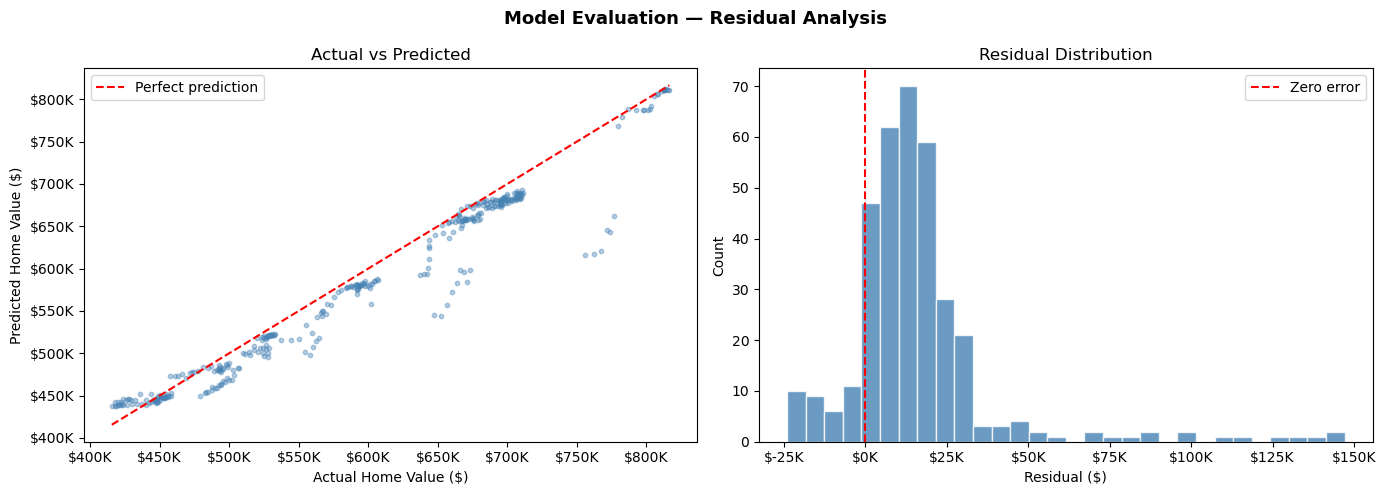

Chart saved.


In [3]:
residuals = y_test - y_pred

print('=== RESIDUAL SUMMARY ===')
print(f'Mean residual   : ${residuals.mean():,.0f}  (close to 0 = unbiased)')
print(f'Std residual    : ${residuals.std():,.0f}')
print(f'Max over-pred   : ${residuals.min():,.0f}')
print(f'Max under-pred  : ${residuals.max():,.0f}')

# Plot residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual Home Value ($)')
axes[0].set_ylabel('Predicted Home Value ($)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Residual distribution
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Model Evaluation — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PREDICTIONS_DIR, 'residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Step 4: Performance by City
Does the model perform equally well across all cities?

In [4]:
test_with_pred = test.copy()
test_with_pred['predicted'] = y_pred
test_with_pred['residual']  = y_test.values - y_pred
test_with_pred['abs_error'] = np.abs(test_with_pred['residual'])

city_performance = test_with_pred.groupby('city').agg(
    actual_mean   = ('home_value', 'mean'),
    predicted_mean= ('predicted',  'mean'),
    mae           = ('abs_error',  'mean'),
    bias          = ('residual',   'mean')
).round(0)

city_performance['mae_pct'] = (city_performance['mae'] / city_performance['actual_mean'] * 100).round(2)

print('=== MODEL PERFORMANCE BY CITY ===')
print(city_performance.sort_values('mae_pct').to_string())

=== MODEL PERFORMANCE BY CITY ===
          actual_mean  predicted_mean      mae     bias  mae_pct
city                                                            
Allen        583421.0        574703.0  11368.0   8718.0     1.95
Plano        558872.0        548365.0  14961.0  10507.0     2.68
McKinney     489548.0        478675.0  15872.0  10873.0     3.24
Frisco       690684.0        666993.0  23715.0  23691.0     3.43
Celina       584005.0        563857.0  20147.0  20147.0     3.45
Prosper      796113.0        762363.0  33812.0  33750.0     4.25


## Step 5: Business Question Answers
Summarizing findings from all five notebooks into clear answers.

In [5]:
print('=' * 65)
print('NORTH DFW HOUSING CRISIS — FINDINGS SUMMARY')
print('=' * 65)

print('''
Q1: Are we heading toward a housing market correction?
──────────────────────────────────────────────────────
YES. The model forecasts price declines across all six cities
over the next 24 months. Prosper leads with a projected -18.6%
correction. This is a soft correction, not a crash — prices
returning toward fundamentals after years of overheating.

Q2: Who is most financially at risk?
──────────────────────────────────────────────────────
Buyers who purchased at peak prices in Prosper and Frisco
between 2021-2023. Current mortgage burden in Prosper exceeds
50% of monthly income — the severely cost-burdened threshold.
Plano's price-to-income ratio of 5.37x crosses into severely
unaffordable territory.

Q3: Is the wage gap the primary driver?
──────────────────────────────────────────────────────
YES. The affordability gap hit -23.5% in 2022 — home prices
grew 23.5 percentage points faster than wages in a single year.
Collin County wages grew 43% from 2015-2024. Home values grew
150-300% over the same period depending on the city.

Q4: What does the next 2 years look like?
──────────────────────────────────────────────────────
A gradual correction. All cities show modest to significant
declines. Allen is essentially flat (+0.3%). McKinney sees the
smallest correction (-2.5%). Prosper faces the steepest drop
(-18.6%) as its market was the most overextended.

Q5: What interventions could realistically help?
──────────────────────────────────────────────────────
Feature importance shows mortgage_rate and supply (total_units)
as top drivers alongside home_value_yoy. This points to two
actionable levers:
1. SUPPLY: Accelerate building permit approvals — especially
   mid-density housing in Frisco and Allen
2. WAGES: Attract higher-paying employers to Collin/Denton
   County to close the affordability gap from the income side
''')

print('=' * 65)

NORTH DFW HOUSING CRISIS — FINDINGS SUMMARY

Q1: Are we heading toward a housing market correction?
──────────────────────────────────────────────────────
YES. The model forecasts price declines across all six cities
over the next 24 months. Prosper leads with a projected -18.6%
correction. This is a soft correction, not a crash — prices
returning toward fundamentals after years of overheating.

Q2: Who is most financially at risk?
──────────────────────────────────────────────────────
Buyers who purchased at peak prices in Prosper and Frisco
between 2021-2023. Current mortgage burden in Prosper exceeds
50% of monthly income — the severely cost-burdened threshold.
Plano's price-to-income ratio of 5.37x crosses into severely
unaffordable territory.

Q3: Is the wage gap the primary driver?
──────────────────────────────────────────────────────
YES. The affordability gap hit -23.5% in 2022 — home prices
grew 23.5 percentage points faster than wages in a single year.
Collin County wages gr

## Step 6: Build Tableau Export Files
Three clean CSV files optimized for Tableau dashboards.

In [6]:
# ── TABLE 1: Home Value History + Forecast ──────────────────────
tableau_prices = predictions[['city', 'zip_code', 'date', 'home_value', 'is_forecast']].copy()
tableau_prices.columns = ['City', 'Zip Code', 'Date', 'Home Value', 'Is Forecast']
tableau_prices.to_csv(os.path.join(TABLEAU_DIR, 'tab_home_values.csv'), index=False)
print(f'tab_home_values.csv saved : {tableau_prices.shape[0]} rows')

# ── TABLE 2: Affordability Metrics Timeline ──────────────────────
tableau_afford = df[[
    'city', 'date', 'home_value', 'median_income',
    'price_to_income_ratio', 'mortgage_burden_pct',
    'affordability_gap', 'affordability_index',
    'mortgage_rate', 'collin_avg_annual_pay'
]].copy()
tableau_afford.columns = [
    'City', 'Date', 'Home Value', 'Median Income',
    'Price to Income Ratio', 'Mortgage Burden Pct',
    'Affordability Gap', 'Affordability Index',
    'Mortgage Rate', 'Avg Annual Pay'
]
tableau_afford.to_csv(os.path.join(TABLEAU_DIR, 'tab_affordability.csv'), index=False)
print(f'tab_affordability.csv saved : {tableau_afford.shape[0]} rows')

# ── TABLE 3: Forecast Summary ────────────────────────────────────
forecast_summary.to_csv(os.path.join(TABLEAU_DIR, 'tab_forecast_summary.csv'))
print(f'tab_forecast_summary.csv saved : {forecast_summary.shape[0]} rows')

# ── TABLE 4: Feature Importance ──────────────────────────────────
importance_df.to_csv(os.path.join(TABLEAU_DIR, 'tab_feature_importance.csv'), index=False)
print(f'tab_feature_importance.csv saved : {importance_df.shape[0]} rows')

tab_home_values.csv saved : 1911 rows
tab_affordability.csv saved : 1755 rows
tab_forecast_summary.csv saved : 6 rows
tab_feature_importance.csv saved : 16 rows


## Step 7: Tableau Dashboard Blueprint
Recommended views to build in Tableau using the exported files.

In [7]:
print('''
TABLEAU DASHBOARD BLUEPRINT
===========================

FILE: tab_home_values.csv
  View 1 — Line chart: Home value over time by city
           Color historical blue, forecast red dashed
           Filter: City selector

FILE: tab_affordability.csv
  View 2 — Dual axis: Home value vs Avg Annual Pay over time
           Shows the widening gap visually
  View 3 — Bar chart: Price-to-Income ratio by city (current)
           Add reference line at 3.0x (healthy benchmark)
  View 4 — Line chart: Mortgage Burden % over time by city
           Add reference lines at 30% and 50% thresholds
  View 5 — Area chart: Affordability gap by year
           Color negative red, positive green

FILE: tab_forecast_summary.csv
  View 6 — Horizontal bar: Forecast % change by city
           Color negative red, positive green

FILE: tab_feature_importance.csv
  View 7 — Horizontal bar: Feature importance scores
           Answers: what is driving prices?

DASHBOARD LAYOUT:
  Page 1 — Executive Summary (Views 3, 6, key stats)
  Page 2 — Price History & Forecast (Views 1, 2)
  Page 3 — Affordability Deep Dive (Views 4, 5)
  Page 4 — Model Insights (Views 7, residual chart)
''')


TABLEAU DASHBOARD BLUEPRINT

FILE: tab_home_values.csv
  View 1 — Line chart: Home value over time by city
           Color historical blue, forecast red dashed
           Filter: City selector

FILE: tab_affordability.csv
  View 2 — Dual axis: Home value vs Avg Annual Pay over time
           Shows the widening gap visually
  View 3 — Bar chart: Price-to-Income ratio by city (current)
           Add reference line at 3.0x (healthy benchmark)
  View 4 — Line chart: Mortgage Burden % over time by city
           Add reference lines at 30% and 50% thresholds
  View 5 — Area chart: Affordability gap by year
           Color negative red, positive green

FILE: tab_forecast_summary.csv
  View 6 — Horizontal bar: Forecast % change by city
           Color negative red, positive green

FILE: tab_feature_importance.csv
  View 7 — Horizontal bar: Feature importance scores
           Answers: what is driving prices?

DASHBOARD LAYOUT:
  Page 1 — Executive Summary (Views 3, 6, key stats)
  Page 

## Step 8: Final Project Summary

In [8]:
print('=' * 65)
print('PROJECT COMPLETE — NORTH DFW HOUSING AFFORDABILITY CRISIS')
print('=' * 65)
print(f'''
NOTEBOOKS COMPLETED
  01 — Data Ingestion       : 6 datasets, 1,755 base rows
  02 — Data Cleaning        : 17-column master dataframe
  03 — Feature Engineering  : 11 new features built
  04 — Predictive Model     : Random Forest, R²=0.933
  05 — Evaluation & Export  : 4 Tableau-ready files

KEY FINDINGS
  Worst affordability gap   : -23.5% in 2022
  Most at-risk city         : Prosper (50.3% mortgage burden)
  Most overvalued           : Plano (5.37x price-to-income)
  Forecast correction       : Prosper -18.6%, Frisco -11.2%
  Model accuracy            : 93.3% R², $18,488 MAE (3.1%)

TABLEAU FILES SAVED TO: data/tableau/
  tab_home_values.csv
  tab_affordability.csv
  tab_forecast_summary.csv
  tab_feature_importance.csv

Next step: Build Tableau dashboard using blueprint above.
''')
print('=' * 65)

PROJECT COMPLETE — NORTH DFW HOUSING AFFORDABILITY CRISIS

NOTEBOOKS COMPLETED
  01 — Data Ingestion       : 6 datasets, 1,755 base rows
  02 — Data Cleaning        : 17-column master dataframe
  03 — Feature Engineering  : 11 new features built
  04 — Predictive Model     : Random Forest, R²=0.933
  05 — Evaluation & Export  : 4 Tableau-ready files

KEY FINDINGS
  Worst affordability gap   : -23.5% in 2022
  Most at-risk city         : Prosper (50.3% mortgage burden)
  Most overvalued           : Plano (5.37x price-to-income)
  Forecast correction       : Prosper -18.6%, Frisco -11.2%
  Model accuracy            : 93.3% R², $18,488 MAE (3.1%)

TABLEAU FILES SAVED TO: data/tableau/
  tab_home_values.csv
  tab_affordability.csv
  tab_forecast_summary.csv
  tab_feature_importance.csv

Next step: Build Tableau dashboard using blueprint above.

